In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

from io import StringIO
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer

from sklearn.pipeline import make_pipeline
from sklearn.feature_extraction import DictVectorizer
from sklearn.preprocessing import OneHotEncoder

from sklearn.feature_selection import RFE
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import HuberRegressor
from sklearn.linear_model import RidgeCV
from sklearn.model_selection import RepeatedKFold

from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error

pd.set_option("display.max_columns", None)

Dataset, remember to decompress zip file in data folder

In [2]:
fps_csv = "../data/fps_videogames.csv"
fps_df = pd.read_csv(fps_csv, na_values=["?"])

EDA

In [3]:
cpu_columns = fps_df.columns.to_list()
cpu_columns = cpu_columns[1:16]
fps_df = fps_df[cpu_columns].copy()

For this project I am going to focus on the cpu features to predict cpu turbo frequency

In [4]:
cpu_column_names = {
    "CpuName" : "cpu",
    "CpuNumberOfCores" : "cpu_cores",
    "CpuNumberOfThreads" : "cpu_threads",
    "CpuBaseClock" : "cpu_clock",
    "CpuCacheL1" : "cpu_L1",
    "CpuCacheL2" : "cpu_L2",
    "CpuCacheL3" : "cpu_L3",
    "CpuDieSize" : "cpu_die",
    "CpuFrequency" : "cpu_frq",
    "CpuMultiplier" : "cpu_multiplier",
    "CpuMultiplierUnlocked" : "cpu_has_oc",
    "CpuProcessSize" : "cpu_prcss",
    "CpuTDP" : "cpu_tdp",
    "CpuNumberOfTransistors" : "cpu_trnsstrs",
    "CpuTurboClock" : "cpu_tclock"
}

In [5]:
fps_df = fps_df.rename(columns=cpu_column_names)

In [6]:
fps_df.columns

Index(['cpu', 'cpu_cores', 'cpu_threads', 'cpu_clock', 'cpu_L1', 'cpu_L2',
       'cpu_L3', 'cpu_die', 'cpu_frq', 'cpu_multiplier', 'cpu_has_oc',
       'cpu_prcss', 'cpu_tdp', 'cpu_trnsstrs', 'cpu_tclock'],
      dtype='object')

CPU Column Descriptions

id: Unique ID for each computer\
cpu: Name of CPU\
cpu_cores: Number of cores in CPU\
cpu_threads: Number of threads in CPU\
cpu_clock: Base clock of CPU\
cpu_L1: Type L1 memory built into microprocessor, storing its recently accessed information\
cpu_L2: Type L2 memory built into microprocessor, storing its recently accessed information\
cpu_L3: Type L3 memory built into microprocessor, storing its recently accessed information\
cpu_die: Physical dimensions (area) of a bare integrated circuit wafer\
cpu_frq: Number of operations per second\
cpu_multiplier: Ratio of an internal clock rate to the externally supplied clock in a CPU\
cpu_has_oc: Denotes if a user is allowed to manually overclock the CPU\
cpu_prcss: Fabrication process used to embed transistors on silicon wafer of chip\
cpu_tdp: Maximum heat a CPU can use in watts\
cpu_trnsstrs: Number of transistors on silicon wafer of chip\
cpu_tclock: Maximum clock of CPU

In [7]:
fps_df.shape

(425833, 15)

To keep this dataset simple I am going to focus on cpu data only

I am going to remove cpu as the name In my eyes does not seem meaningful and encoding is going to end up in higher dimensionality

In [8]:
fps_df = fps_df.drop("cpu", axis=1)

In [9]:
fps_df.shape

(425833, 14)

Look for Duplicates

In [10]:
#Leaving this step for later after imputation has been done
#fps_df.duplicated().sum()

In [11]:
fps_df_cp = fps_df.copy()
#fps_df_clean = fps_df_clean.drop_duplicates()
fps_df_cp.shape

(425833, 14)

Look for missing values

In [12]:
missing_null = fps_df_cp.isnull().sum()
missing_na = fps_df_cp.isna().sum()
missing = missing_null+missing_na
missing_features = missing[missing>0].index.to_list()
missing_features

['cpu_L3', 'cpu_die', 'cpu_trnsstrs']

cpu_L3 feature refers to L3 cache in cpu, nan can be replaced for 0, means it does not have it

In [13]:
def value_replace(df_cp, column, to_replace, value):
    return df_cp[column].replace(to_replace=to_replace, value=value)

In [14]:
fps_df_cp["cpu_L3"] = value_replace(fps_df_cp, "cpu_L3", np.nan, value=0)

Set Datatype, from info output you can see that cache values are of int type, it was initialized as float64

In [15]:
fps_df_cp["cpu_L3"] = fps_df_cp["cpu_L3"].astype(int)

In [16]:
def propagate_valid(df_cp, ff_col, order_col, ascending):
    sorted_df = df_cp.sort_values(by=order_col, ascending=ascending)
    return sorted_df[ff_col].ffill()

In [17]:
#fps_df_clean["cpu_die"] = value_replace(fps_df_clean, "cpu_die", np.nan, value=0.0)
fps_df_cp["cpu_die"] = propagate_valid(fps_df_cp, "cpu_die", "cpu_prcss", True)

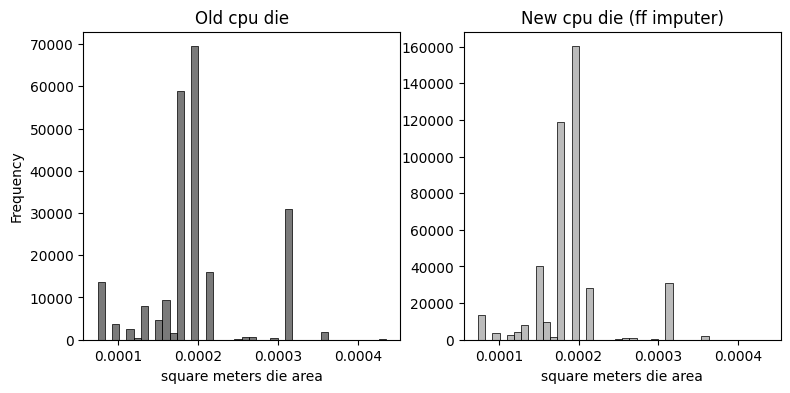

In [18]:
old_cpu_die = fps_df["cpu_die"]
new_cpu_die = fps_df_cp["cpu_die"]

X_LBL = "square meters die area"
Y_LBL = "Frequency"
old = "old die"
new = "new die (imputed)"
CLR_1 = "#222222"
CLR_2 = "#aaaaaa"

fig_act_prd, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 4))

sns.histplot(old_cpu_die, label=old, color=CLR_1, alpha=0.6, bins=40, ax=ax1)
ax1.set_title("Old cpu die")
ax1.set_xlabel(X_LBL)
ax1.set_ylabel(Y_LBL)

sns.histplot(new_cpu_die, label=new, color=CLR_2, alpha=0.8, bins=40, ax=ax2)
ax2.set_title("New cpu die (ff imputer)")
ax2.set_xlabel(X_LBL)
ax2.set_ylabel("")

plt.show()

cpu_trnsstrs in real life must be greater than zero using ffill as did in cpu_die

In [19]:
#fps_df_clean["cpu_trnsstrs"] = value_replace(fps_df_clean, "cpu_trnsstrs", np.nan, value=0.0)
fps_df_cp["cpu_trnsstrs"] = propagate_valid(fps_df_cp, "cpu_trnsstrs", "cpu_prcss", True)

In [20]:
fps_df_cp["cpu_trnsstrs"] = fps_df_cp["cpu_trnsstrs"].astype(int)

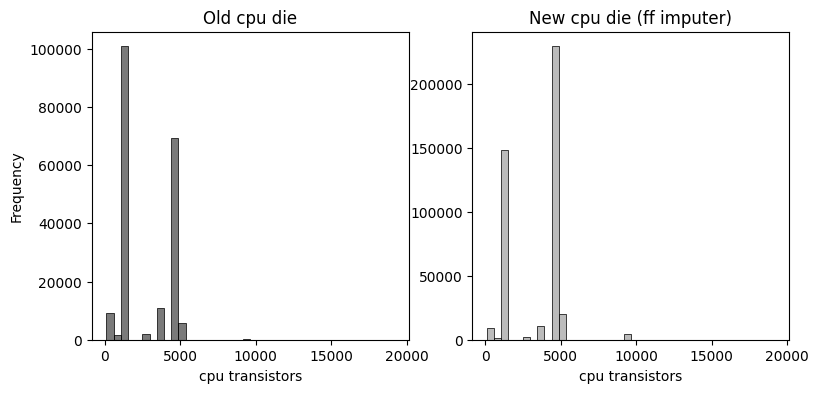

In [21]:
old_cpu_die = fps_df["cpu_trnsstrs"]
new_cpu_die = fps_df_cp["cpu_trnsstrs"]

X_LBL = "cpu transistors"
Y_LBL = "Frequency"
old = "old die"
new = "new die (imputed)"
CLR_1 = "#222222"
CLR_2 = "#aaaaaa"

fig_act_prd, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 4))

sns.histplot(old_cpu_die, label=old, color=CLR_1, alpha=0.6, bins=40, ax=ax1)
ax1.set_title("Old cpu die")
ax1.set_xlabel(X_LBL)
ax1.set_ylabel(Y_LBL)

sns.histplot(new_cpu_die, label=new, color=CLR_2, alpha=0.8, bins=40, ax=ax2)
ax2.set_title("New cpu die (ff imputer)")
ax2.set_xlabel(X_LBL)
ax2.set_ylabel("")

plt.show()

Duplicates

In [22]:
fps_df_cp.duplicated().sum()

np.int64(424970)

In [23]:
fps_df_clean = fps_df_cp.copy()
fps_df_clean = fps_df_clean.drop_duplicates()
fps_df_clean.shape

(863, 14)

Turn cpu_has_oc to categorical

In [24]:
fps_df_clean["cpu_has_oc"] = fps_df_clean["cpu_has_oc"].apply(lambda val: "Y" if val == 0 else "N")
fps_df_clean["cpu_has_oc"] = fps_df_clean["cpu_has_oc"].astype("object")
fps_df_clean.sample(4)

,cpu_cores,cpu_threads,cpu_clock,cpu_L1,cpu_L2,cpu_L3,cpu_die,cpu_frq,cpu_multiplier,cpu_has_oc,cpu_prcss,cpu_tdp,cpu_trnsstrs,cpu_tclock
141663,2,4,100,128,512,3,0.000177,2100,21.0,Y,14,15,4800,2100
36459,4,8,100,256,1024,10,0.000294,3600,36.0,N,32,130,1270,3800
60982,6,12,100,384,1536,12,0.000210,3700,37.0,N,14,95,4950,4700
43485,4,4,100,256,1024,6,0.000177,2800,28.0,Y,14,62,4800,3600


One thing I did not do was trying to put features in terms of the same unit if features share a unit between them e.g. express MHz in GHz for frequency this to maintain consistency during model training and aid in interpretability also if possible avoid Standardization

In [25]:
#express all frequencies in GHz
to_ghz = ["cpu_clock", "cpu_frq", "cpu_tclock"]
for col in to_ghz:
    fps_df_clean[col] = fps_df_clean[col].apply(lambda val: np.round(val/1000, 6)).astype(float)
fps_df_clean.sample(4)

,cpu_cores,cpu_threads,cpu_clock,cpu_L1,cpu_L2,cpu_L3,cpu_die,cpu_frq,cpu_multiplier,cpu_has_oc,cpu_prcss,cpu_tdp,cpu_trnsstrs,cpu_tclock
28324,18,36,0.1,1152,18432,24,0.000192,2.6,26.0,N,14,165,4800,4.4
201303,8,16,0.1,512,2048,16,0.000150,3.1,31.0,Y,14,65,1400,5.0
37411,12,24,0.1,1152,6144,64,0.000074,3.8,38.0,N,7,105,3800,4.6
50848,6,6,0.1,384,1536,9,0.000149,3.7,37.0,N,14,95,4950,4.6


In [26]:
#express all MB in GB
to_gb = ["cpu_L1", "cpu_L2", "cpu_L3"]
for col in to_gb:
    fps_df_clean[col] = fps_df_clean[col].apply(lambda val: np.round(val/1_000, 6)).astype(float)
fps_df_clean.sample(4)

,cpu_cores,cpu_threads,cpu_clock,cpu_L1,cpu_L2,cpu_L3,cpu_die,cpu_frq,cpu_multiplier,cpu_has_oc,cpu_prcss,cpu_tdp,cpu_trnsstrs,cpu_tclock
116861,6,6,0.1,0.384,1.536,0.009,0.000150,2.9,29.0,Y,14,65,1400,4.1
196239,4,4,0.1,0.256,1.024,0.006,0.000123,3.8,38.0,N,14,91,1400,4.2
28628,2,4,0.1,0.128,0.512,0.003,0.000094,3.4,34.0,Y,22,55,1400,3.4
195400,6,6,0.1,0.384,1.536,0.009,0.000177,2.8,28.0,Y,14,65,3800,4.0


cpu_die should be expressed in mm², I am not sure if the unit of the available values is square meters or any other thing this difficults the conversion. But I can still try.

As die sizes shrink due to advancements in semiconductor technology, the power density—measured in watts per square millimeter—increases, making it more challenging to dissipate heat efficiently

In [27]:
#cpu die in mm² (square mm)
fps_df_clean["cpu_die"] = fps_df_clean["cpu_die"].apply(lambda val: np.round(val*1_000_000, 6)).astype(int)
fps_df_clean.sample(4)

,cpu_cores,cpu_threads,cpu_clock,cpu_L1,cpu_L2,cpu_L3,cpu_die,cpu_frq,cpu_multiplier,cpu_has_oc,cpu_prcss,cpu_tdp,cpu_trnsstrs,cpu_tclock
44572,2,4,0.1,0.128,0.512,0.003,123,2.2,22.0,Y,14,15,4800,2.7
89934,8,16,0.1,0.512,2.048,0.016,192,4.0,40.0,N,14,127,4800,5.0
115391,8,16,0.1,0.512,2.048,0.016,210,3.6,36.0,N,14,95,4950,5.0
256581,4,4,0.1,0.256,1.024,0.008,210,4.0,40.0,N,14,91,4950,4.0


cpu_trnsstrs in modern cpus this value should be expressed in billions, in the dataset it seems to be expressed in millions. I am converting it to billions.

In [28]:
#cpu_trnsstrs in billions
fps_df_clean["cpu_trnsstrs"] = fps_df_clean["cpu_trnsstrs"].apply(lambda val: np.round(val/1_000, 6)).astype(float)
fps_df_clean.sample(4)

,cpu_cores,cpu_threads,cpu_clock,cpu_L1,cpu_L2,cpu_L3,cpu_die,cpu_frq,cpu_multiplier,cpu_has_oc,cpu_prcss,cpu_tdp,cpu_trnsstrs,cpu_tclock
100237,4,4,0.1,0.256,1.024,0.008,150,4.0,40.0,N,14,91,1.40,4.0
189207,2,4,0.1,0.128,0.512,0.004,177,3.7,37.0,Y,14,51,9.60,3.7
45760,4,8,0.1,0.256,1.024,0.008,177,4.0,40.0,Y,14,95,1.40,4.2
3756,4,4,0.1,0.256,1.024,0.006,210,3.8,38.0,N,14,91,4.95,4.2


In [29]:
def get_numeric_features(df):
    num_ftrs = list(df.select_dtypes(include=["int64", "float64"]).columns)
    return num_ftrs

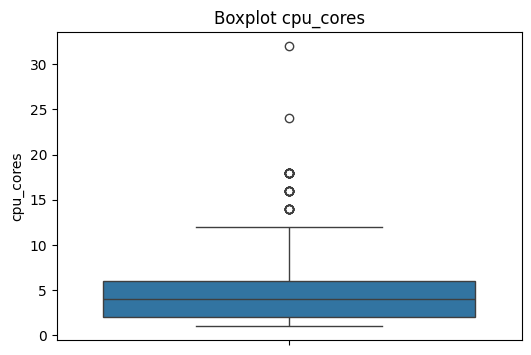

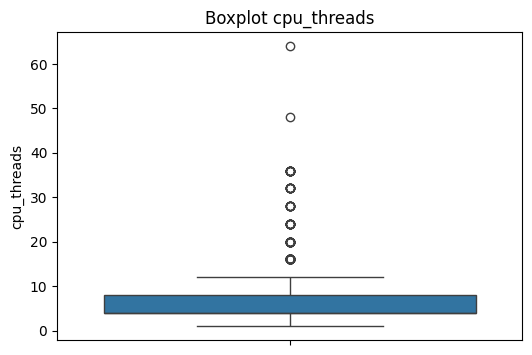

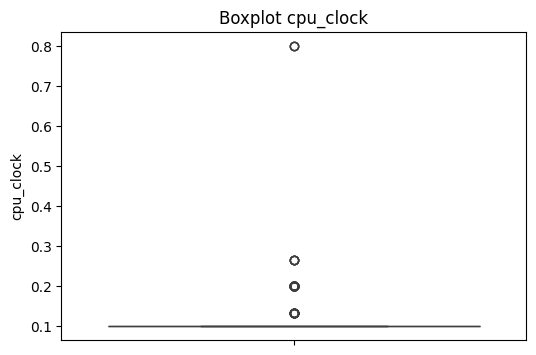

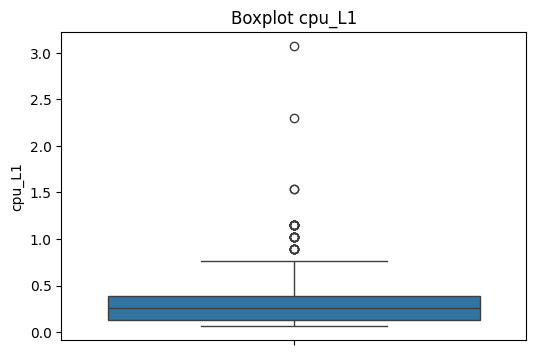

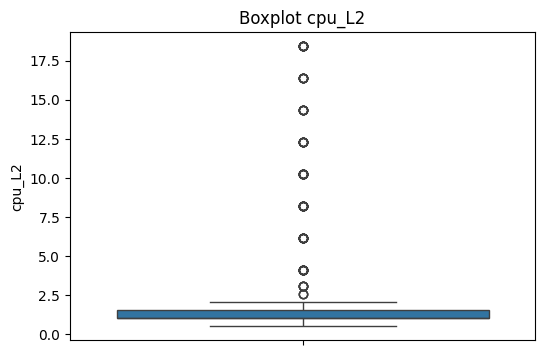

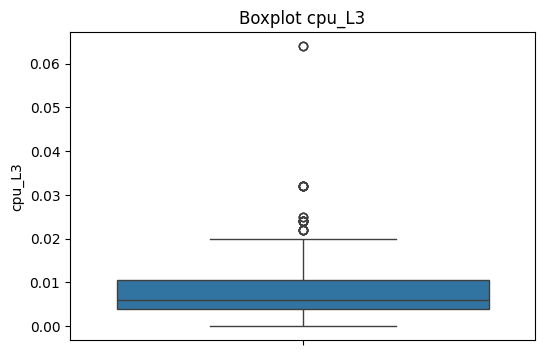

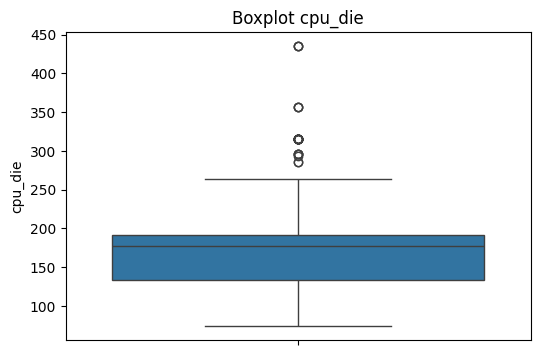

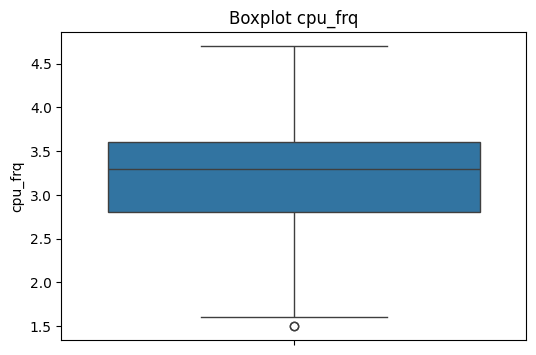

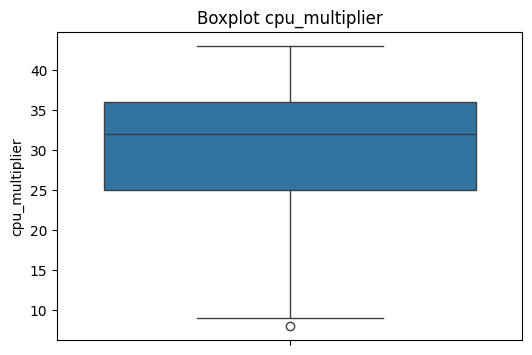

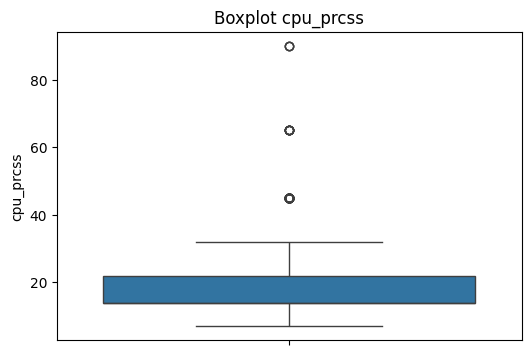

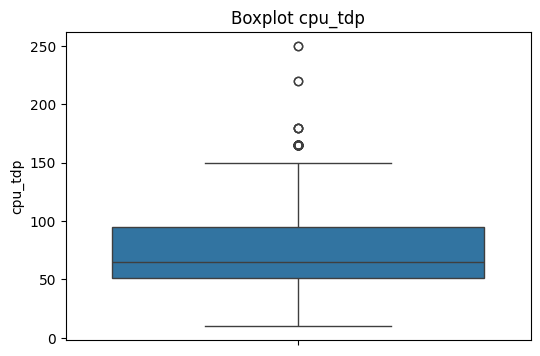

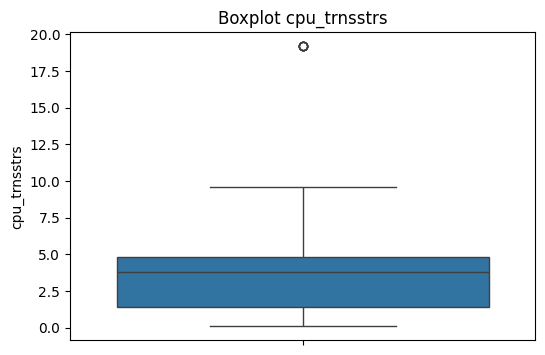

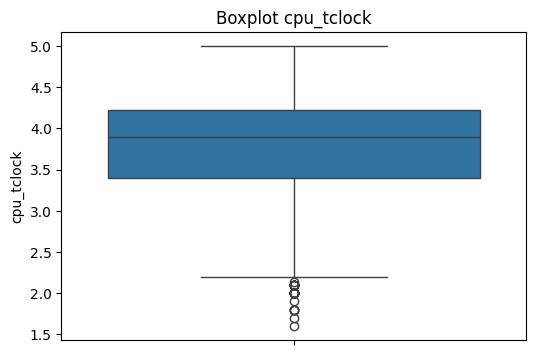

In [30]:
num_ftrs = get_numeric_features(fps_df_clean)
for num_ftr in fps_df_clean[num_ftrs]:
    plt.figure(figsize=(6,4))
    sns.boxplot(fps_df_clean[num_ftr])
    plt.title(f"Boxplot {num_ftr}")

Many cpu features have outliers, Linear models are particularly affected by outliers it may be better to use IQR to put a boundarie for each feature with outliers but the available data is has already suffered from duplicate removal

Determine number of outliers in each feature using IQR

In [31]:
#default multiplier is 1.5. increased allows for more robustness to outliers
def get_feature_outliers(df, feature, multiplier=1.5):
    perc25 = df[feature].quantile(0.25)
    perc75 = df[feature].quantile(0.75)
    iqr = perc75-perc25
    above= perc75 + multiplier * iqr
    below = perc25 - multiplier * iqr
    outlier_rows = df[(df[feature]>above) | (df[feature]<below)]
    return outlier_rows.shape[0]

Cpu features and how many outliers they have

In [32]:
for ftr in num_ftrs:
    print(f"Outliers in {ftr}: {get_feature_outliers(fps_df_clean, ftr, multiplier=3)}")

Outliers in cpu_cores: 2
Outliers in cpu_threads: 44
Outliers in cpu_clock: 99
Outliers in cpu_L1: 4
Outliers in cpu_L2: 107
Outliers in cpu_L3: 12
Outliers in cpu_die: 3
Outliers in cpu_frq: 0
Outliers in cpu_multiplier: 0
Outliers in cpu_prcss: 11
Outliers in cpu_tdp: 2
Outliers in cpu_trnsstrs: 6
Outliers in cpu_tclock: 0


I have few observations and removing outliers seems to not be a good idea for the moment

Linear Relationship, target feature is cpu turbo frequency

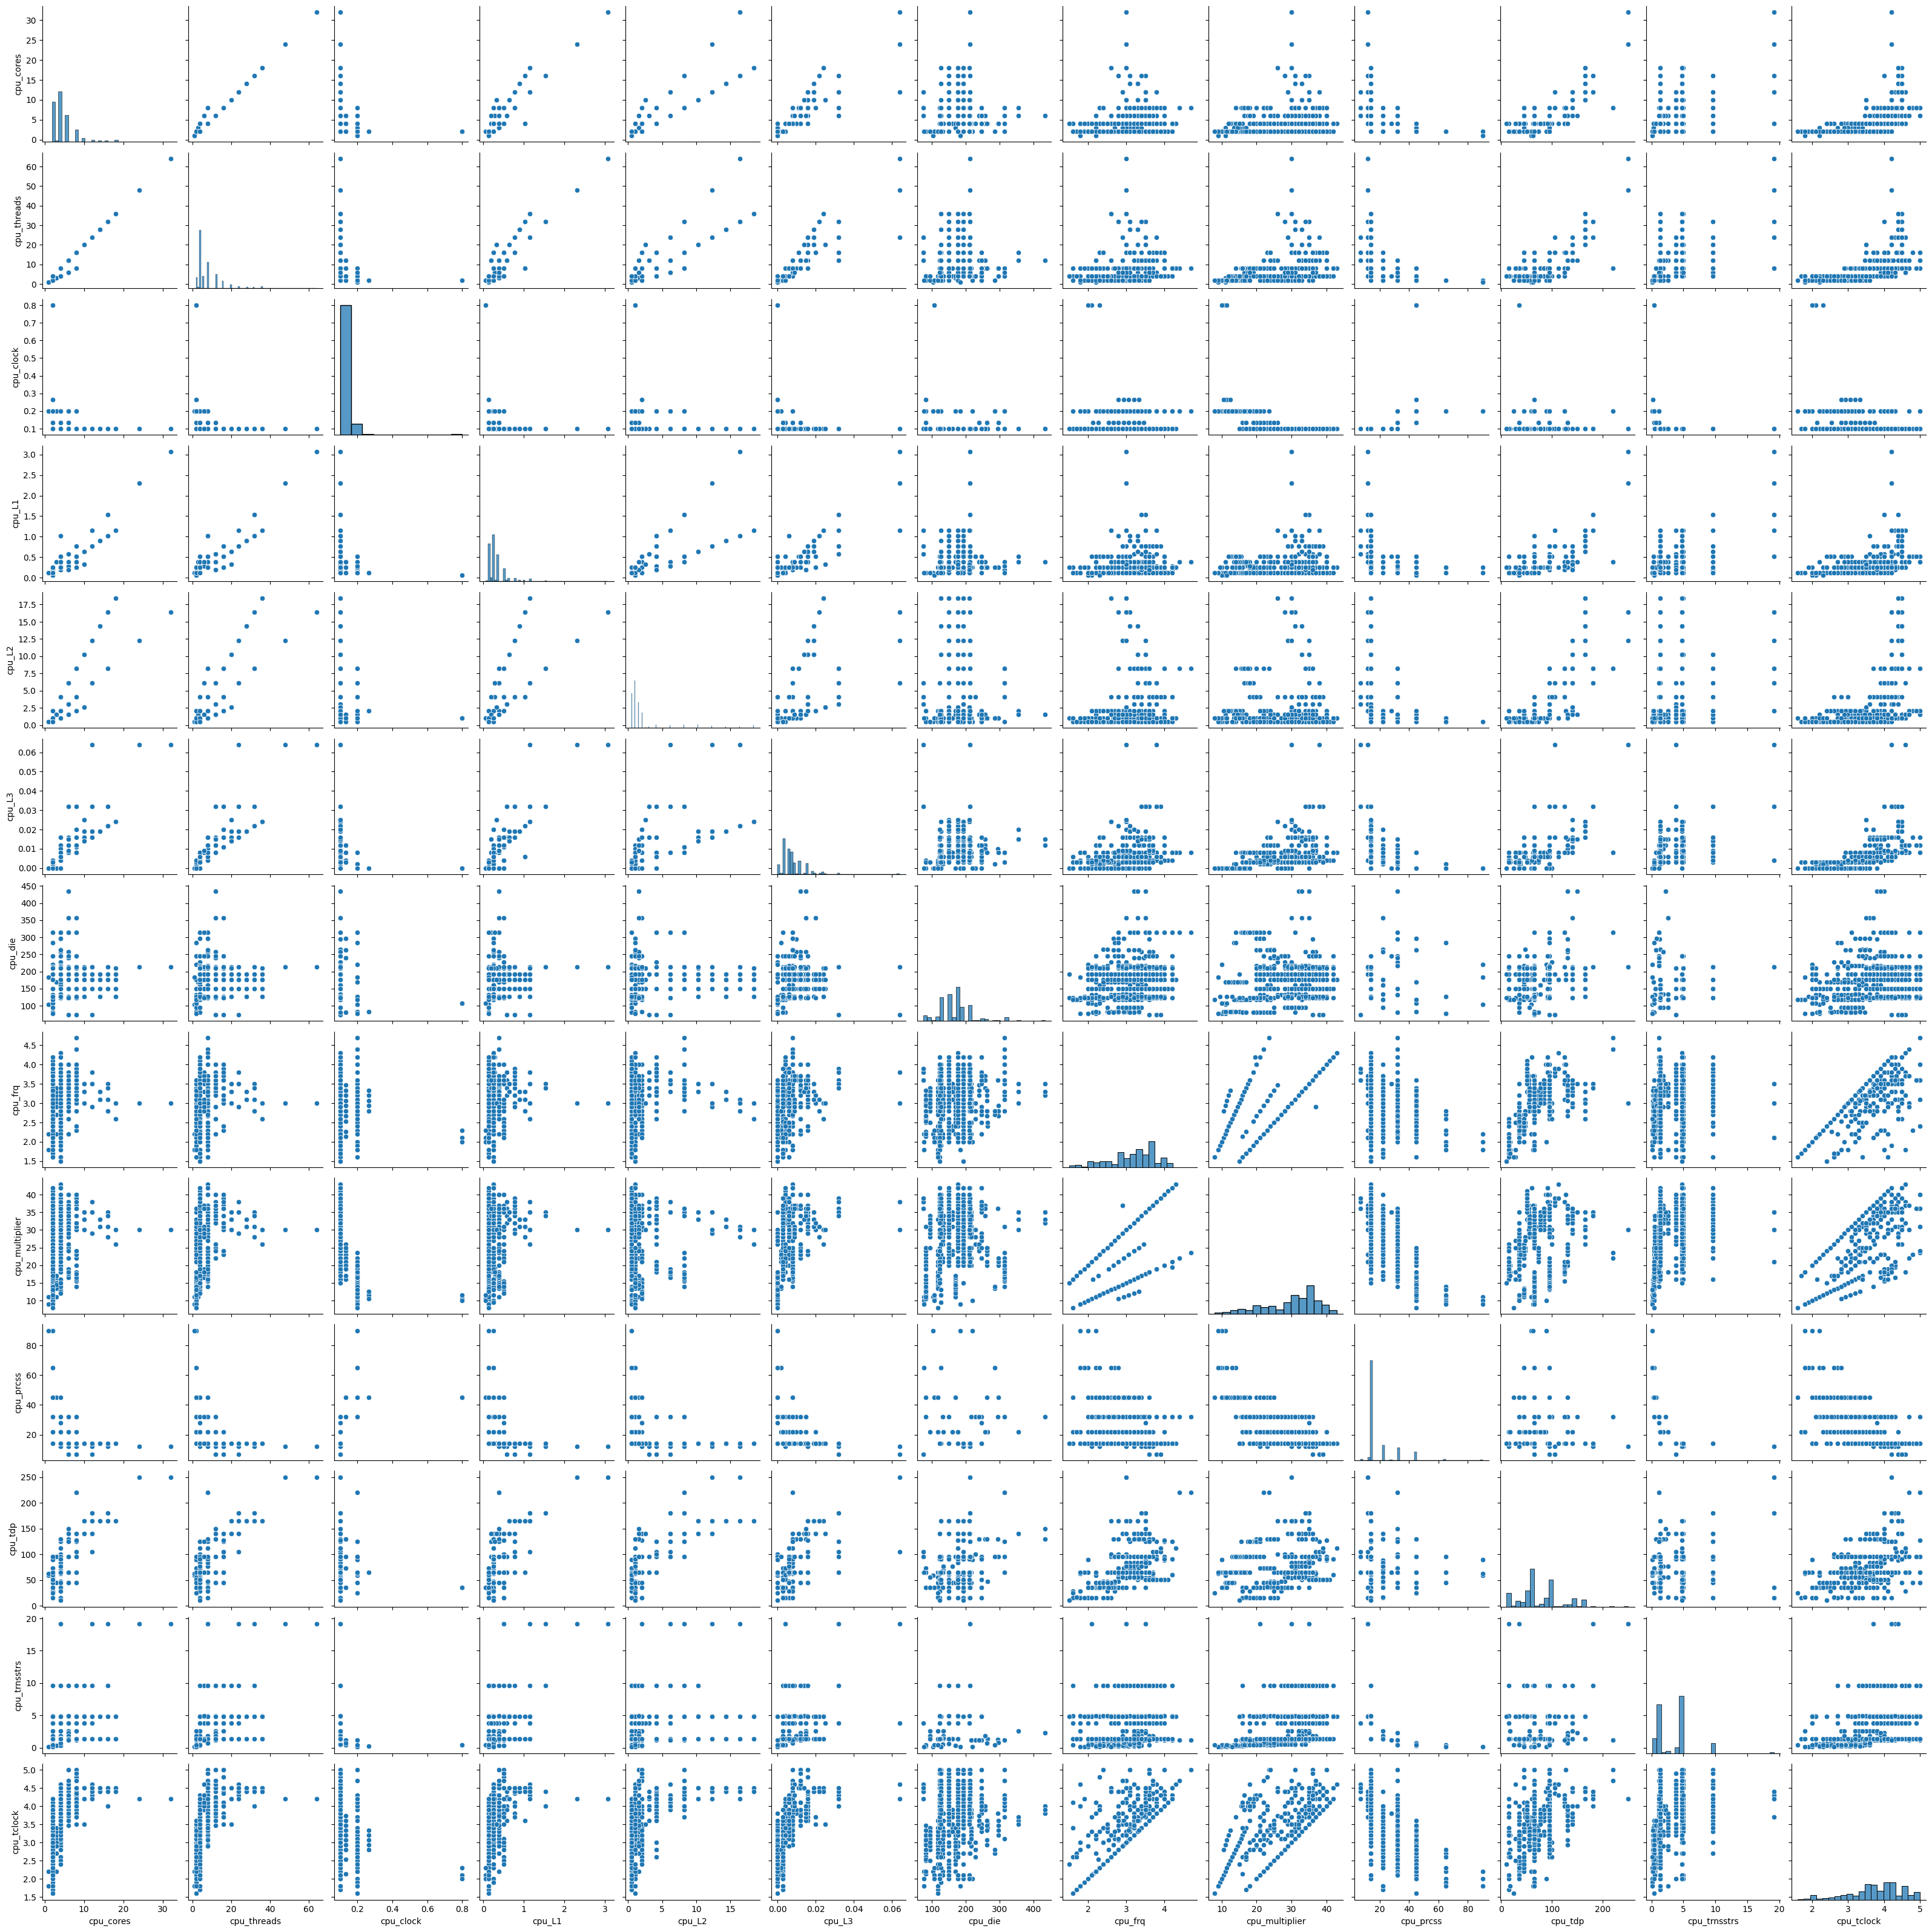

In [33]:
sns.pairplot(fps_df_clean[num_ftrs])

There seem to be some linear relationships cpu_tdp, cpu_frq, cpu_multiplier, cpu_die

Numerical Features Correlation

In [34]:
num_ftrs.remove("cpu_tclock")

In [35]:
#corr of numerical features using absolute value to consider negative correlations
corr_mtrx = fps_df_clean[num_ftrs].corr().abs()
#pivot column names and order in descending order 
corr_pairs = corr_mtrx.unstack().sort_values(ascending=False)
#filter matrix diagonal and remove duplicate feature pair entries
bggst_corr = corr_pairs[corr_pairs < 1.0].drop_duplicates()

In [36]:
bggst_corr[bggst_corr>0.4]

cpu_threads     cpu_cores         0.939703
cpu_cores       cpu_L1            0.920234
cpu_threads     cpu_L1            0.874458
cpu_L3          cpu_threads       0.864900
cpu_L2          cpu_cores         0.864343
cpu_cores       cpu_L3            0.861820
cpu_threads     cpu_L2            0.849741
cpu_L1          cpu_L3            0.813294
cpu_multiplier  cpu_frq           0.806419
cpu_L2          cpu_L1            0.788394
cpu_tdp         cpu_cores         0.767508
                cpu_threads       0.710435
                cpu_L2            0.694226
cpu_L3          cpu_tdp           0.679870
cpu_tdp         cpu_L1            0.660437
cpu_prcss       cpu_multiplier    0.636946
cpu_L3          cpu_L2            0.617078
cpu_clock       cpu_prcss         0.576660
                cpu_multiplier    0.495400
cpu_frq         cpu_tdp           0.486857
cpu_prcss       cpu_trnsstrs      0.479272
dtype: float64

Start simple using all features

Split data

In [37]:
train, test_vldtn = train_test_split(fps_df_clean, test_size=0.4, random_state=42)
vldtn, test = train_test_split(test_vldtn, test_size=0.5, random_state=42)
print(len(train))
print(len(test_vldtn))
print(len(vldtn))
print(len(test))

517
346
173
173


The change in the split sizes from the previous zero fill and this imputation is due to the removal of duplicates previously done to the imputation in the zero fill and the duplicate removal after the imputation in this case

In [38]:
train = train.reset_index(drop=True)
vldtn = vldtn.reset_index(drop=True)
test = test.reset_index(drop=True)

y_train = train.cpu_tclock.values
y_vldtn = vldtn.cpu_tclock.values
y_test = test.cpu_tclock.values

target = "cpu_tclock"
del train[target]
del vldtn[target]
del test[target]

Train split

In [39]:
def get_numeric_categoric_features(df):
    num_ftrs = list(df.select_dtypes(include=["int64", "float64"]).columns)
    ctgrcl_ftrs = list(df.select_dtypes(include=["object"]).columns)
    return num_ftrs, ctgrcl_ftrs

In [40]:
def scale_train_features(train_df):
    num_ftrs, ctgrcl_ftrs = get_numeric_categoric_features(train_df)
    clmn_trnsfrm = ColumnTransformer(
        transformers=[
            #("num", StandardScaler(), num_ftrs),
            ("cat", OneHotEncoder(sparse_output=False, handle_unknown="ignore"), ctgrcl_ftrs)
        ],
        verbose_feature_names_out=True
    )
    X_num = train_df[num_ftrs]
    X_trnsfrm = clmn_trnsfrm.fit_transform(train_df[ctgrcl_ftrs])
    X_enc = pd.DataFrame(X_trnsfrm, columns=[clmn_trnsfrm.get_feature_names_out()])
    X_scl_enc = pd.concat([X_num, X_enc], axis=1)

    return X_scl_enc

In [41]:
def scale_test_features(train_df, test_df):
    num_ftrs, ctgrcl_ftrs = get_numeric_categoric_features(train_df)
    clmn_trnsfrm = ColumnTransformer(
        transformers=[
            #("num", StandardScaler(), num_ftrs),
            ("cat", OneHotEncoder(sparse_output=False, handle_unknown="ignore"), ctgrcl_ftrs)
        ],
        verbose_feature_names_out=True
    )
    clmn_trnsfrm.fit(train_df[ctgrcl_ftrs])

    X_num = test_df[num_ftrs]
    X_trnsfrm = clmn_trnsfrm.transform(test_df[ctgrcl_ftrs])
    X_enc = pd.DataFrame(X_trnsfrm, columns=[clmn_trnsfrm.get_feature_names_out()])
    X_scl_enc = pd.concat([X_num, X_enc], axis=1)
    
    return X_scl_enc

In [42]:
X_train = scale_train_features(train)

In [43]:
X_train.head()

,cpu_cores,cpu_threads,cpu_clock,cpu_L1,cpu_L2,cpu_L3,cpu_die,cpu_frq,cpu_multiplier,cpu_prcss,cpu_tdp,cpu_trnsstrs,"(cat__cpu_has_oc_N,)","(cat__cpu_has_oc_Y,)"
0,6,12,0.1,0.384,1.536,0.012,177,3.7,37.0,14,95,4.8,1.0,0.0
1,4,4,0.1,0.256,1.024,0.006,133,3.2,32.0,22,77,2.6,0.0,1.0
2,2,4,0.1,0.128,0.512,0.003,150,3.7,37.0,14,51,1.4,0.0,1.0
3,4,4,0.1,0.256,1.024,0.006,177,2.7,27.0,14,65,4.8,0.0,1.0
4,4,4,0.1,0.256,1.024,0.006,177,3.0,30.0,14,65,4.8,0.0,1.0


In [44]:
X_train_mlr = sm.add_constant(X_train)

In [45]:
simple_mlr = sm.OLS(y_train, X_train_mlr).fit()

In [46]:
simple_mlr.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.808
Model:                            OLS   Adj. R-squared:                  0.804
Method:                 Least Squares   F-statistic:                     163.3
Date:                Fri, 14 Nov 2025   Prob (F-statistic):          5.72e-171
Time:                        14:58:26   Log-Likelihood:                -158.30
No. Observations:                 517   AIC:                             344.6
Df Residuals:                     503   BIC:                             404.1
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
==========================================================================================
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                      0.8074      0.110      7.366      0.000       0.592       1.023
cpu_cores                  0.3058      0.021     14.372      0.000       0.264       0.348
cpu_threads                0.0125      0.008      1.544      0.123      -0.003       0.028
cpu_clock                 -0.6733      0.383     -1.758      0.079      -1.426       0.079
cpu_L1                    -0.9477      0.168     -5.633      0.000      -1.278      -0.617
cpu_L2                    -0.1003      0.012     -8.186      0.000      -0.124      -0.076
cpu_L3                   -23.3057      7.212     -3.231      0.001     -37.476      -9.136
cpu_die                 9.437e-05      0.000      0.277      0.782      -0.001       0.001
cpu_frq                    0.8558      0.064     13.469      0.000       0.731       0.981
cpu_multiplier            -0.0091      0.006     -1.527      0.127      -0.021       0.003
cpu_prcss                 -0.0078      0.003     -2.861      0.004      -0.013      -0.002
cpu_tdp                   -0.0064      0.001     -6.358      0.000      -0.008      -0.004
cpu_trnsstrs              -0.0035      0.006     -0.559      0.577      -0.016       0.009
('cat__cpu_has_oc_N',)     0.5278      0.067      7.910      0.000       0.397       0.659
('cat__cpu_has_oc_Y',)     0.2796      0.050      5.584      0.000       0.181       0.378
==============================================================================
Omnibus:                       71.927   Durbin-Watson:                   2.018
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              502.942
Skew:                          -0.337   Prob(JB):                    6.13e-110
Kurtosis:                       7.785   Cond. No.                     3.32e+17
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The smallest eigenvalue is 1.8e-28. This might indicate that there are
strong multicollinearity problems or that the design matrix is singular.
"""

In [47]:
def get_summary_df(model):
    ols_summary_data = model.summary().tables[1].as_html()
    ols_summary_df = pd.read_html(StringIO(ols_summary_data), header=0, index_col=0)[0]
    #ols_summary_df = ols_summary_df[ols_summary_df["P>|t|"]<=0.005]
    idx_cols = ols_summary_df.index.to_list()
    ols_summary_df.index = [x[0][len("cat__"):] if x[0].startswith("cat") else x for x in idx_cols]
    return ols_summary_df

In [48]:
ols_df = get_summary_df(simple_mlr)
ols_df

,coef,std err,t,P>|t|,[0.025,0.975]
const,0.807400,0.110,7.366,0.000,0.592,1.023
cpu_cores,0.305800,0.021,14.372,0.000,0.264,0.348
cpu_threads,0.012500,0.008,1.544,0.123,-0.003,0.028
cpu_clock,-0.673300,0.383,-1.758,0.079,-1.426,0.079
cpu_L1,-0.947700,0.168,-5.633,0.000,-1.278,-0.617
cpu_L2,-0.100300,0.012,-8.186,0.000,-0.124,-0.076
cpu_L3,-23.305700,7.212,-3.231,0.001,-37.476,-9.136
cpu_die,0.000094,0.000,0.277,0.782,-0.001,0.001
cpu_frq,0.855800,0.064,13.469,0.000,0.731,0.981
cpu_multiplier,-0.009100,0.006,-1.527,0.127,-0.021,0.003


Variance Inflation Factor

In [49]:
X_train.columns.to_flat_index()[-2][0][len("cat__"):-2]

'cpu_has_oc'

In [50]:
def get_vif(df):
    vif = pd.DataFrame()
    vif["features"] = df.columns.to_flat_index()
    vif["features"] = vif["features"].apply(lambda x: x[0][len("cat__"):] if x[0].startswith("cat") else x)
    observations = df.values
    n_features = df.shape[1]
    vif["vif_score"] = [variance_inflation_factor(observations, idx) for idx in range(n_features)]
    vif = vif.sort_values(by="vif_score", ascending=False)
    return vif

In [51]:
vif_scores = get_vif(X_train)
vif_scores

,features,vif_score
13,cpu_has_oc_Y,73.764104
12,cpu_has_oc_N,50.431922
0,cpu_cores,25.554775
1,cpu_threads,16.429981
5,cpu_L3,10.407325
8,cpu_multiplier,9.963668
4,cpu_L2,9.244551
3,cpu_L1,8.712254
10,cpu_tdp,7.542517
7,cpu_frq,7.047394


At this point what is left is consider the P value and the vif scores to filter the features one feature at a time

Each time a feature is removed a new model has to be trained as the feature in turn when combined with other features can be of significance and affect other feature significance

when the P values and vid scores of each all features reach acceptable values then those features are selected to build the final model.

VIF scores netween 5-10 have to be inspected as moderate multicollinearity may be acceptable

VIF scores above 10 indicates high collinearity either remove or take corrective action

VIF scores below 5 stay

Using Feature Ranking with Recursive Feature Elimination

In [52]:
vif_scores["features"].size

14

In [53]:
X_train.columns = X_train.columns.astype(str)

In [54]:
#columns = pd.Series(X_train.columns.to_flat_index()).apply(lambda x: x[0][len("num__"):])
columns = pd.Series(vif_scores["features"].values)
columns

0       cpu_has_oc_Y
1       cpu_has_oc_N
2          cpu_cores
3        cpu_threads
4             cpu_L3
5     cpu_multiplier
6             cpu_L2
7             cpu_L1
8            cpu_tdp
9            cpu_frq
10         cpu_prcss
11         cpu_clock
12      cpu_trnsstrs
13           cpu_die
dtype: object

In [55]:
simple_mlr_rfe = LinearRegression()
simple_mlr_rfe.fit(X_train, y_train)

#starting with all features I can end up with less as process refines
desired_features=14
rfe = RFE(simple_mlr_rfe, n_features_to_select=desired_features, step=1)
rfe = rfe.fit(X_train, y_train)

important_features = list(zip(columns, rfe.support_, rfe.ranking_))

In [56]:
imp_ftrs_df = pd.DataFrame(important_features, columns=["feature", "recommended", "importance"])
imp_ftrs_df = imp_ftrs_df.sort_values(by=["importance"], ascending=True).reset_index(drop=True)
imp_ftrs_df

,feature,recommended,importance
0,cpu_has_oc_Y,True,1
1,cpu_has_oc_N,True,1
2,cpu_cores,True,1
3,cpu_threads,True,1
4,cpu_L3,True,1
5,cpu_multiplier,True,1
6,cpu_L2,True,1
7,cpu_L1,True,1
8,cpu_tdp,True,1
9,cpu_frq,True,1


Now build a model with recommended features prioritize pvalue over vif_score to consider removal

In [57]:
selected_features = imp_ftrs_df.feature.iloc[1:14]
selected_features.values[0] = selected_features.values[0][0:-2]
selected_features = selected_features.to_list()

In [58]:
#selected_features.append("cpu_prcss")
selected_features

['cpu_has_oc',
 'cpu_cores',
 'cpu_threads',
 'cpu_L3',
 'cpu_multiplier',
 'cpu_L2',
 'cpu_L1',
 'cpu_tdp',
 'cpu_frq',
 'cpu_prcss',
 'cpu_clock',
 'cpu_trnsstrs',
 'cpu_die']

In [59]:
X_train_rfe = scale_train_features(train[selected_features])

In [60]:
X_train_mlr_rfe = sm.add_constant(X_train_rfe)

In [61]:
simple_mlr_rfe = sm.OLS(y_train, X_train_mlr_rfe).fit()

In [62]:
ols_rfe_df = get_summary_df(simple_mlr_rfe)
ols_rfe_df

,coef,std err,t,P>|t|,[0.025,0.975]
const,0.807400,0.110,7.366,0.000,0.592,1.023
cpu_cores,0.305800,0.021,14.372,0.000,0.264,0.348
cpu_threads,0.012500,0.008,1.544,0.123,-0.003,0.028
cpu_L3,-23.305700,7.212,-3.231,0.001,-37.476,-9.136
cpu_multiplier,-0.009100,0.006,-1.527,0.127,-0.021,0.003
cpu_L2,-0.100300,0.012,-8.186,0.000,-0.124,-0.076
cpu_L1,-0.947700,0.168,-5.633,0.000,-1.278,-0.617
cpu_tdp,-0.006400,0.001,-6.358,0.000,-0.008,-0.004
cpu_frq,0.855800,0.064,13.469,0.000,0.731,0.981
cpu_prcss,-0.007800,0.003,-2.861,0.004,-0.013,-0.002


In [63]:
vif_rfe_scores = get_vif(X_train_rfe)
vif_rfe_scores

,features,vif_score
13,cpu_has_oc_Y,73.764104
12,cpu_has_oc_N,50.431922
0,cpu_cores,25.554775
1,cpu_threads,16.429981
2,cpu_L3,10.407325
3,cpu_multiplier,9.963668
4,cpu_L2,9.244551
5,cpu_L1,8.712254
6,cpu_tdp,7.542517
7,cpu_frq,7.047394


cpu_has_oc has significant p-value but is highly correlated with other features

In [64]:
selected_features.remove("cpu_has_oc")
selected_features

['cpu_cores',
 'cpu_threads',
 'cpu_L3',
 'cpu_multiplier',
 'cpu_L2',
 'cpu_L1',
 'cpu_tdp',
 'cpu_frq',
 'cpu_prcss',
 'cpu_clock',
 'cpu_trnsstrs',
 'cpu_die']

In [65]:
X_train_rfe = scale_train_features(train[selected_features])

In [66]:
X_train_mlr_rfe = sm.add_constant(X_train_rfe)

In [67]:
simple_mlr_rfe = sm.OLS(y_train, X_train_mlr_rfe).fit()

In [68]:
ols_rfe_df = get_summary_df(simple_mlr_rfe)
ols_rfe_df

,coef,std err,t,P>|t|,[0.025,0.975]
const,0.8308,0.155,5.367,0.000,0.527,1.135
cpu_cores,0.3080,0.022,14.048,0.000,0.265,0.351
cpu_threads,0.0098,0.008,1.179,0.239,-0.007,0.026
cpu_L3,-20.7856,7.419,-2.802,0.005,-35.362,-6.209
cpu_multiplier,-0.0073,0.006,-1.203,0.229,-0.019,0.005
cpu_L2,-0.0929,0.013,-7.400,0.000,-0.118,-0.068
cpu_L1,-0.8599,0.173,-4.980,0.000,-1.199,-0.521
cpu_tdp,-0.0060,0.001,-5.784,0.000,-0.008,-0.004
cpu_frq,0.9056,0.065,13.964,0.000,0.778,1.033
cpu_prcss,-0.0078,0.003,-2.784,0.006,-0.013,-0.002


In [69]:
vif_rfe_scores = get_vif(X_train_rfe)
vif_rfe_scores

,features,vif_score
7,cpu_frq,188.895582
3,cpu_multiplier,122.001118
0,cpu_cores,69.393331
1,cpu_threads,36.602309
2,cpu_L3,26.714284
6,cpu_tdp,22.797853
5,cpu_L1,22.421465
11,cpu_die,14.774379
4,cpu_L2,13.005847
8,cpu_prcss,9.918494


cpu_frq has significant p-value but is highly correlated with other features

In [70]:
selected_features.remove("cpu_frq")
selected_features

['cpu_cores',
 'cpu_threads',
 'cpu_L3',
 'cpu_multiplier',
 'cpu_L2',
 'cpu_L1',
 'cpu_tdp',
 'cpu_prcss',
 'cpu_clock',
 'cpu_trnsstrs',
 'cpu_die']

In [71]:
X_train_rfe = scale_train_features(train[selected_features])

In [72]:
X_train_mlr_rfe = sm.add_constant(X_train_rfe)

In [73]:
simple_mlr_rfe = sm.OLS(y_train, X_train_mlr_rfe).fit()

In [74]:
ols_rfe_df = get_summary_df(simple_mlr_rfe)
ols_rfe_df

,coef,std err,t,P>|t|,[0.025,0.975]
const,1.0129,0.181,5.581,0.000,0.656,1.369
cpu_cores,0.2791,0.026,10.869,0.000,0.229,0.330
cpu_threads,-0.0245,0.009,-2.624,0.009,-0.043,-0.006
cpu_L3,-9.7566,8.679,-1.124,0.261,-26.808,7.295
cpu_multiplier,0.0597,0.004,13.484,0.000,0.051,0.068
cpu_L2,-0.0623,0.015,-4.279,0.000,-0.091,-0.034
cpu_L1,-0.6546,0.202,-3.234,0.001,-1.052,-0.257
cpu_tdp,-0.0014,0.001,-1.186,0.236,-0.004,0.001
cpu_prcss,-0.0013,0.003,-0.391,0.696,-0.008,0.005
cpu_clock,1.5784,0.428,3.690,0.000,0.738,2.419


In [75]:
vif_rfe_scores = get_vif(X_train_rfe)
vif_rfe_scores

,features,vif_score
0,cpu_cores,69.050602
1,cpu_threads,33.397648
2,cpu_L3,26.410875
5,cpu_L1,22.311136
6,cpu_tdp,20.220475
3,cpu_multiplier,14.208238
10,cpu_die,14.023733
4,cpu_L2,12.571236
7,cpu_prcss,9.072937
8,cpu_clock,8.026679


cpu_cores has significant p-value but is highly correlated with other features

In [76]:
selected_features.remove("cpu_cores")
selected_features

['cpu_threads',
 'cpu_L3',
 'cpu_multiplier',
 'cpu_L2',
 'cpu_L1',
 'cpu_tdp',
 'cpu_prcss',
 'cpu_clock',
 'cpu_trnsstrs',
 'cpu_die']

In [77]:
X_train_rfe = scale_train_features(train[selected_features])

In [78]:
X_train_mlr_rfe = sm.add_constant(X_train_rfe)

In [79]:
simple_mlr_rfe = sm.OLS(y_train, X_train_mlr_rfe).fit()

In [80]:
ols_rfe_df = get_summary_df(simple_mlr_rfe)
ols_rfe_df

,coef,std err,t,P>|t|,[0.025,0.975]
const,1.6679,0.190,8.780,0.000,1.295,2.041
cpu_threads,-0.0032,0.010,-0.320,0.749,-0.023,0.017
cpu_L3,20.0214,9.139,2.191,0.029,2.066,37.976
cpu_multiplier,0.0473,0.005,9.967,0.000,0.038,0.057
cpu_L2,-0.0104,0.015,-0.681,0.496,-0.040,0.020
cpu_L1,0.5924,0.185,3.202,0.001,0.229,0.956
cpu_tdp,0.0031,0.001,2.622,0.009,0.001,0.005
cpu_prcss,-0.0127,0.003,-3.725,0.000,-0.019,-0.006
cpu_clock,1.7384,0.474,3.665,0.000,0.806,2.670
cpu_trnsstrs,-0.0142,0.008,-1.674,0.095,-0.031,0.002


In [81]:
vif_rfe_scores = get_vif(X_train_rfe)
vif_rfe_scores

,features,vif_score
0,cpu_threads,31.833528
1,cpu_L3,23.416316
5,cpu_tdp,19.316861
4,cpu_L1,15.717444
2,cpu_multiplier,14.136936
9,cpu_die,13.651965
3,cpu_L2,10.727492
6,cpu_prcss,8.886470
7,cpu_clock,7.823345
8,cpu_trnsstrs,3.868032


cpu_threads now does not have a significant p-value and is highly correlated with other features

In [82]:
selected_features.remove("cpu_threads")
selected_features

['cpu_L3',
 'cpu_multiplier',
 'cpu_L2',
 'cpu_L1',
 'cpu_tdp',
 'cpu_prcss',
 'cpu_clock',
 'cpu_trnsstrs',
 'cpu_die']

In [83]:
X_train_rfe = scale_train_features(train[selected_features])

In [84]:
X_train_mlr_rfe = sm.add_constant(X_train_rfe)

In [85]:
simple_mlr_rfe = sm.OLS(y_train, X_train_mlr_rfe).fit()

In [86]:
ols_rfe_df = get_summary_df(simple_mlr_rfe)
ols_rfe_df

,coef,std err,t,P>|t|,[0.025,0.975]
const,1.6644,0.189,8.784,0.000,1.292,2.037
cpu_L3,18.0790,6.830,2.647,0.008,4.661,31.497
cpu_multiplier,0.0473,0.005,9.974,0.000,0.038,0.057
cpu_L2,-0.0135,0.012,-1.155,0.249,-0.037,0.009
cpu_L1,0.5815,0.182,3.201,0.001,0.225,0.938
cpu_tdp,0.0032,0.001,2.674,0.008,0.001,0.005
cpu_prcss,-0.0128,0.003,-3.762,0.000,-0.020,-0.006
cpu_clock,1.7539,0.471,3.720,0.000,0.828,2.680
cpu_trnsstrs,-0.0143,0.008,-1.682,0.093,-0.031,0.002
cpu_die,0.0014,0.000,3.129,0.002,0.001,0.002


In [87]:
vif_rfe_scores = get_vif(X_train_rfe)
vif_rfe_scores

,features,vif_score
4,cpu_tdp,18.774601
3,cpu_L1,15.182958
1,cpu_multiplier,13.501318
8,cpu_die,13.409847
0,cpu_L3,12.678139
5,cpu_prcss,8.703095
6,cpu_clock,7.763824
2,cpu_L2,5.873230
7,cpu_trnsstrs,3.865100


Wow I am impressed here as cpu_tdp became less significant, this must be result of the remaining features and their relationship

In [88]:
selected_features.remove("cpu_tdp")
selected_features

['cpu_L3',
 'cpu_multiplier',
 'cpu_L2',
 'cpu_L1',
 'cpu_prcss',
 'cpu_clock',
 'cpu_trnsstrs',
 'cpu_die']

In [89]:
X_train_rfe = scale_train_features(train[selected_features])

In [90]:
X_train_mlr_rfe = sm.add_constant(X_train_rfe)

In [91]:
simple_mlr_rfe = sm.OLS(y_train, X_train_mlr_rfe).fit()

In [92]:
ols_rfe_df = get_summary_df(simple_mlr_rfe)
ols_rfe_df

,coef,std err,t,P>|t|,[0.025,0.975]
const,1.3817,0.158,8.734,0.000,1.071,1.693
cpu_L3,26.6584,6.066,4.395,0.000,14.741,38.576
cpu_multiplier,0.0558,0.004,15.931,0.000,0.049,0.063
cpu_L2,0.0052,0.009,0.546,0.585,-0.013,0.024
cpu_L1,0.5340,0.182,2.936,0.003,0.177,0.891
cpu_prcss,-0.0075,0.003,-2.691,0.007,-0.013,-0.002
cpu_clock,1.8903,0.472,4.009,0.000,0.964,2.817
cpu_trnsstrs,-0.0143,0.009,-1.672,0.095,-0.031,0.002
cpu_die,0.0017,0.000,3.935,0.000,0.001,0.003


In [93]:
vif_rfe_scores = get_vif(X_train_rfe)
vif_rfe_scores

,features,vif_score
3,cpu_L1,14.956419
7,cpu_die,13.341325
1,cpu_multiplier,10.518829
0,cpu_L3,10.330817
5,cpu_clock,7.663286
4,cpu_prcss,7.565211
2,cpu_L2,4.298087
6,cpu_trnsstrs,3.827037


cpu_L1 has significant p-value but is highly correlated with other features

In [94]:
selected_features.remove("cpu_L1")
selected_features

['cpu_L3',
 'cpu_multiplier',
 'cpu_L2',
 'cpu_prcss',
 'cpu_clock',
 'cpu_trnsstrs',
 'cpu_die']

In [95]:
X_train_rfe = scale_train_features(train[selected_features])

In [96]:
X_train_mlr_rfe = sm.add_constant(X_train_rfe)

In [97]:
simple_mlr_rfe = sm.OLS(y_train, X_train_mlr_rfe).fit()

In [98]:
ols_rfe_df = get_summary_df(simple_mlr_rfe)
ols_rfe_df

,coef,std err,t,P>|t|,[0.025,0.975]
const,1.4161,0.159,8.909,0.000,1.104,1.728
cpu_L3,38.0686,4.692,8.114,0.000,28.851,47.287
cpu_multiplier,0.0551,0.004,15.639,0.000,0.048,0.062
cpu_L2,0.0216,0.008,2.808,0.005,0.006,0.037
cpu_prcss,-0.0059,0.003,-2.156,0.032,-0.011,-0.001
cpu_clock,1.8019,0.474,3.801,0.000,0.870,2.733
cpu_trnsstrs,-0.0064,0.008,-0.785,0.433,-0.022,0.010
cpu_die,0.0016,0.000,3.736,0.000,0.001,0.002


In [99]:
vif_rfe_scores = get_vif(X_train_rfe)
vif_rfe_scores

,features,vif_score
6,cpu_die,13.317598
1,cpu_multiplier,10.511495
4,cpu_clock,7.650767
3,cpu_prcss,7.072572
0,cpu_L3,6.110598
5,cpu_trnsstrs,3.403555
2,cpu_L2,2.779425


cpu_die has a significant p-value is highly correlated with other features

In [100]:
selected_features.remove("cpu_die")
selected_features

['cpu_L3',
 'cpu_multiplier',
 'cpu_L2',
 'cpu_prcss',
 'cpu_clock',
 'cpu_trnsstrs']

In [101]:
X_train_rfe = scale_train_features(train[selected_features])

In [102]:
X_train_mlr_rfe = sm.add_constant(X_train_rfe)

In [103]:
simple_mlr_rfe = sm.OLS(y_train, X_train_mlr_rfe).fit()

In [104]:
ols_rfe_df = get_summary_df(simple_mlr_rfe)
ols_rfe_df

,coef,std err,t,P>|t|,[0.025,0.975]
const,1.5785,0.155,10.196,0.000,1.274,1.883
cpu_L3,38.4835,4.750,8.102,0.000,29.152,47.815
cpu_multiplier,0.0564,0.004,15.916,0.000,0.049,0.063
cpu_L2,0.0247,0.008,3.194,0.001,0.010,0.040
cpu_prcss,-0.0037,0.003,-1.364,0.173,-0.009,0.002
cpu_clock,1.7433,0.480,3.633,0.000,0.801,2.686
cpu_trnsstrs,-0.0004,0.008,-0.045,0.964,-0.016,0.016


In [105]:
vif_rfe_scores = get_vif(X_train_rfe)
vif_rfe_scores

,features,vif_score
4,cpu_clock,7.613455
1,cpu_multiplier,7.113163
0,cpu_L3,6.108291
3,cpu_prcss,5.830131
5,cpu_trnsstrs,3.151757
2,cpu_L2,2.727336


I have reached a good point to analyze features as vif_scores are below 10 closing to desired range

When you use cpu_clock and cpu_multiplier you can get the cpu_freq so this values even though correlated are significant

In the other hand cpu_L3 and cpu_L2 do not seem of any help in determining cpu turbo frequency at all so theoretically I find it better to remove them and bring back cpu_die and cpu_tdp aeven though they can have a high correlation I would like to see how they behave with the remaining features and of course accept a certain level of correlation hopefully the vif_score of each is close to 5

cpu_L3 and cpu_L2 are not kept for the next model

In [106]:
selected_features.remove("cpu_L3")
selected_features.remove("cpu_L2")
selected_features

['cpu_multiplier', 'cpu_prcss', 'cpu_clock', 'cpu_trnsstrs']

In [107]:
X_train_rfe = scale_train_features(train[selected_features])

In [108]:
X_train_mlr_rfe = sm.add_constant(X_train_rfe)

In [109]:
simple_mlr_rfe = sm.OLS(y_train, X_train_mlr_rfe).fit()

In [110]:
ols_rfe_df = get_summary_df(simple_mlr_rfe)
ols_rfe_df

,coef,std err,t,P>|t|,[0.025,0.975]
const,1.8347,0.181,10.116,0.000,1.478,2.191
cpu_multiplier,0.0603,0.004,14.891,0.000,0.052,0.068
cpu_prcss,-0.0090,0.003,-2.841,0.005,-0.015,-0.003
cpu_clock,1.9346,0.567,3.412,0.001,0.821,3.048
cpu_trnsstrs,0.0237,0.009,2.556,0.011,0.005,0.042


In [111]:
vif_rfe_scores = get_vif(X_train_rfe)
vif_rfe_scores

,features,vif_score
2,cpu_clock,7.491521
1,cpu_prcss,5.761886
0,cpu_multiplier,5.295164
3,cpu_trnsstrs,2.894247


considering cpu_tdp and cpu_die again

In [112]:
selected_features.append("cpu_tdp")
selected_features.append("cpu_die")
selected_features

['cpu_multiplier',
 'cpu_prcss',
 'cpu_clock',
 'cpu_trnsstrs',
 'cpu_tdp',
 'cpu_die']

In [113]:
X_train_rfe = scale_train_features(train[selected_features])

In [114]:
X_train_rfe = scale_train_features(train[selected_features])

In [115]:
X_train_mlr_rfe = sm.add_constant(X_train_rfe)

In [116]:
simple_mlr_rfe = sm.OLS(y_train, X_train_mlr_rfe).fit()

In [117]:
ols_rfe_df = get_summary_df(simple_mlr_rfe)
ols_rfe_df

,coef,std err,t,P>|t|,[0.025,0.975]
const,2.0805,0.168,12.398,0.000,1.751000,2.410
cpu_multiplier,0.0385,0.004,10.050,0.000,0.031000,0.046
cpu_prcss,-0.0193,0.003,-6.816,0.000,-0.025000,-0.014
cpu_clock,1.4138,0.488,2.898,0.004,0.455000,2.372
cpu_trnsstrs,0.0040,0.008,0.487,0.626,-0.012000,0.020
cpu_tdp,0.0074,0.001,12.458,0.000,0.006000,0.009
cpu_die,0.0010,0.000,2.151,0.032,0.000085,0.002


In [118]:
vif_rfe_scores = get_vif(X_train_rfe)
vif_rfe_scores

,features,vif_score
5,cpu_die,13.325217
0,cpu_multiplier,10.374995
2,cpu_clock,7.556060
1,cpu_prcss,6.961955
4,cpu_tdp,5.918077
3,cpu_trnsstrs,3.195945


Well cpu_die is still highly correlated but cpu_tdp got closer to be less correlated

So I am only keeping cpu_tdp

In [119]:
selected_features.remove("cpu_die")
selected_features

['cpu_multiplier', 'cpu_prcss', 'cpu_clock', 'cpu_trnsstrs', 'cpu_tdp']

In [120]:
X_train_rfe = scale_train_features(train[selected_features])

In [121]:
X_train_rfe = scale_train_features(train[selected_features])

In [122]:
X_train_mlr_rfe = sm.add_constant(X_train_rfe)

In [123]:
simple_mlr_rfe = sm.OLS(y_train, X_train_mlr_rfe).fit()

In [124]:
ols_rfe_df = get_summary_df(simple_mlr_rfe)
ols_rfe_df

,coef,std err,t,P>|t|,[0.025,0.975]
const,2.2041,0.158,13.932,0.000,1.893,2.515
cpu_multiplier,0.0382,0.004,9.960,0.000,0.031,0.046
cpu_prcss,-0.0185,0.003,-6.571,0.000,-0.024,-0.013
cpu_clock,1.3623,0.489,2.786,0.006,0.402,2.323
cpu_trnsstrs,0.0073,0.008,0.901,0.368,-0.009,0.023
cpu_tdp,0.0077,0.001,13.513,0.000,0.007,0.009


In [125]:
vif_rfe_scores = get_vif(X_train_rfe)
vif_rfe_scores

,features,vif_score
0,cpu_multiplier,7.867311
2,cpu_clock,7.495648
1,cpu_prcss,5.965636
4,cpu_tdp,5.666797
3,cpu_trnsstrs,2.924882


Interesting cpu_trnsstrs is not significant but has low correlation with other features

In [126]:
selected_features.remove("cpu_trnsstrs")
selected_features

['cpu_multiplier', 'cpu_prcss', 'cpu_clock', 'cpu_tdp']

In [127]:
X_train_rfe = scale_train_features(train[selected_features])

In [128]:
X_train_rfe = scale_train_features(train[selected_features])

In [129]:
X_train_mlr_rfe = sm.add_constant(X_train_rfe)

In [130]:
simple_mlr_rfe = sm.OLS(y_train, X_train_mlr_rfe).fit()

In [131]:
ols_rfe_df = get_summary_df(simple_mlr_rfe)
ols_rfe_df

,coef,std err,t,P>|t|,[0.025,0.975]
const,2.2499,0.150,15.018,0.000,1.956,2.544
cpu_multiplier,0.0380,0.004,9.923,0.000,0.030,0.046
cpu_prcss,-0.0195,0.003,-7.503,0.000,-0.025,-0.014
cpu_clock,1.3629,0.489,2.788,0.006,0.402,2.323
cpu_tdp,0.0078,0.001,13.809,0.000,0.007,0.009


In [132]:
vif_rfe_scores = get_vif(X_train_rfe)
vif_rfe_scores

,features,vif_score
2,cpu_clock,7.349286
0,cpu_multiplier,6.188185
3,cpu_tdp,5.607443
1,cpu_prcss,5.574932


Well at this point p-values are significant but cpu_clock only by 0.001 difference, i can accept that

In case of the vif_scores I understand that there is correlation and it would be good to look at some metrics here testing the model in such conditions

Residuals

It is time to predict using training data and look at the distribution of the residuals

In [133]:
y_prdct = simple_mlr_rfe.predict(X_train_mlr_rfe)

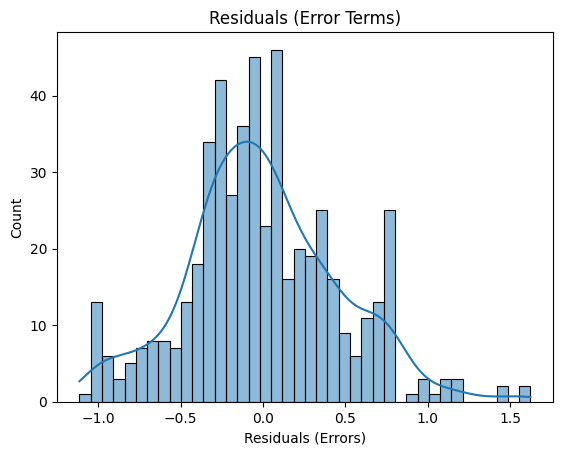

In [134]:
y_plot = y_train-y_prdct
sns.histplot(y_plot, bins=40, kde=True)
plt.title("Residuals (Error Terms)")
plt.xlabel("Residuals (Errors)")
plt.show()

Residuals are close to a normal distribution, the effect of multicollinearity and outliers is shown in the distribution but overall the approximation is fair after selecting most important features.

Using validation data

In [135]:
X_vldtn = scale_test_features(train[selected_features], vldtn[selected_features])

In [136]:
X_vldtn_mlr = sm.add_constant(X_vldtn)

In [137]:
y_prdct_vldtn = np.round(simple_mlr_rfe.predict(X_vldtn_mlr),3)

In [138]:
#rmse, lower is better, predicted values are closer to observed values
def rmse(y, y_pred):
    error = y_pred - y
    mse = (error ** 2).mean()
    return np.sqrt(mse)

In [139]:
print(y_vldtn[:20])

[3.7   4.5   4.1   4.    4.4   3.7   3.6   4.2   3.7   3.9   4.6   3.6
 3.6   4.    4.6   3.8   4.1   4.    3.8   3.333]


In [140]:
print(y_prdct_vldtn[:20])

0     4.380
1     3.453
2     3.301
3     3.913
4     4.465
5     3.951
6     3.774
7     3.989
8     3.223
9     3.324
10    3.837
11    3.661
12    3.880
13    4.344
14    4.261
15    4.498
16    3.723
17    4.223
18    3.956
19    3.093
dtype: float64


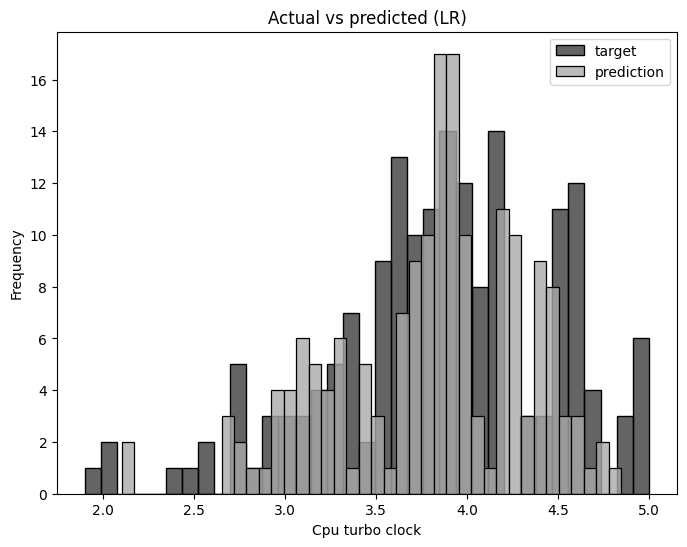

In [141]:
X_LBL = "Cpu turbo clock"
Y_LBL = "Frequency"
TRGT = "target"
PRDCT = "prediction"
CLR_1 = "#222222"
CLR_2 = "#aaaaaa"

fig_act_prd, (ax1) = plt.subplots(1, 1, figsize=(8, 6))

sns.histplot(y_vldtn, label=TRGT, color=CLR_1, alpha=0.7, bins=35, ax=ax1)
sns.histplot(y_prdct_vldtn, label=PRDCT, color=CLR_2, alpha=0.8, bins=40, ax=ax1)
ax1.set_title("Actual vs predicted (LR)")
ax1.set_xlabel(X_LBL)
ax1.set_ylabel(Y_LBL)

plt.legend()
plt.show()

In [142]:
rmse_vldtn = rmse(y_vldtn, y_prdct_vldtn)
print(rmse_vldtn)
print(y_vldtn.std())

0.44791001496158817
0.6304913200202967


In [143]:
r2_score(y_true=y_vldtn, y_pred=y_prdct_vldtn)

0.49531160079332703

In [144]:
mae_vldtn = mean_absolute_error(y_vldtn, y_prdct_vldtn)
print(mae_vldtn)

0.3416473988439306


After using the validation data it is necessary to use a different model approach as outliers and the high multicollinearity affect the model ability to explain the variance of the dependent variable and the RMSE penalizes heavily the presence of outliers.

Use HubberRegressor

In [145]:
#using default values, except max_iter I set it to 200
hub_reg = HuberRegressor(epsilon=1.35, alpha=0.001, max_iter=100, tol=1e-05)
hub_reg.fit(X_train_rfe, y_train)

,epsilon,1.35
,max_iter,100
,alpha,0.001
,warm_start,False
,fit_intercept,True
,tol,1e-05


In [146]:
y_prdct_vldtn = hub_reg.predict(X_vldtn)

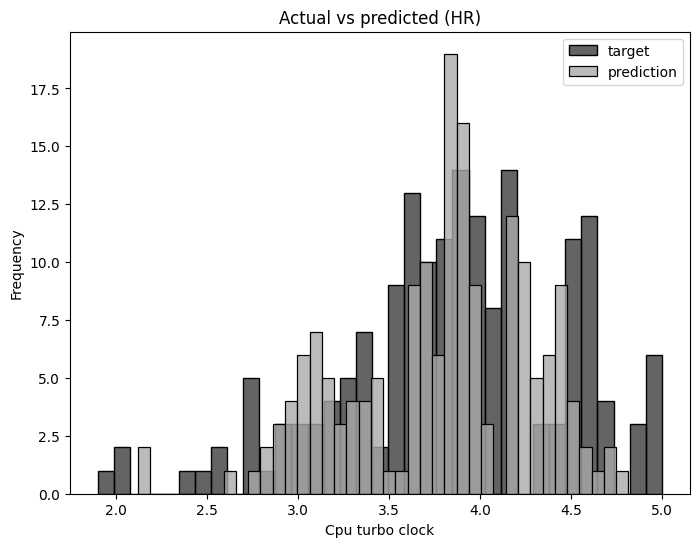

In [147]:
X_LBL = "Cpu turbo clock"
Y_LBL = "Frequency"
TRGT = "target"
PRDCT = "prediction"
CLR_1 = "#222222"
CLR_2 = "#aaaaaa"

fig_act_prd, (ax1) = plt.subplots(1, 1, figsize=(8, 6))

sns.histplot(y_vldtn, label=TRGT, color=CLR_1, alpha=0.7, bins=35, ax=ax1)
sns.histplot(y_prdct_vldtn, label=PRDCT, color=CLR_2, alpha=0.8, bins=40, ax=ax1)
ax1.set_title("Actual vs predicted (HR)")
ax1.set_xlabel(X_LBL)
ax1.set_ylabel(Y_LBL)

plt.legend()
plt.show()

In [148]:
rmse_vldtn = rmse(y_vldtn, y_prdct_vldtn)
print(rmse_vldtn)

0.4420961099394729


In [149]:
r2_score(y_true=y_vldtn, y_pred=y_prdct_vldtn)

0.5083283549965216

In [150]:
mae_vldtn = mean_absolute_error(y_vldtn, y_prdct_vldtn)
print(mae_vldtn)

0.32976401506544945


Use RidgeCV

In [151]:
cv = RepeatedKFold(n_splits=10, n_repeats=5, random_state=42)

In [152]:
np.linspace(0, 1, 101)

array([0.  , 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1 ,
       0.11, 0.12, 0.13, 0.14, 0.15, 0.16, 0.17, 0.18, 0.19, 0.2 , 0.21,
       0.22, 0.23, 0.24, 0.25, 0.26, 0.27, 0.28, 0.29, 0.3 , 0.31, 0.32,
       0.33, 0.34, 0.35, 0.36, 0.37, 0.38, 0.39, 0.4 , 0.41, 0.42, 0.43,
       0.44, 0.45, 0.46, 0.47, 0.48, 0.49, 0.5 , 0.51, 0.52, 0.53, 0.54,
       0.55, 0.56, 0.57, 0.58, 0.59, 0.6 , 0.61, 0.62, 0.63, 0.64, 0.65,
       0.66, 0.67, 0.68, 0.69, 0.7 , 0.71, 0.72, 0.73, 0.74, 0.75, 0.76,
       0.77, 0.78, 0.79, 0.8 , 0.81, 0.82, 0.83, 0.84, 0.85, 0.86, 0.87,
       0.88, 0.89, 0.9 , 0.91, 0.92, 0.93, 0.94, 0.95, 0.96, 0.97, 0.98,
       0.99, 1.  ])

In [153]:
rdg_cv = RidgeCV(alphas=np.linspace(0, 1, 101), cv=cv, scoring="neg_mean_absolute_error")

In [154]:
rdg_cv.fit(X_train_rfe, y_train)

,alphas,"array([0. , ... 0.99, 1. ])"
,fit_intercept,True
,scoring,'neg_mean_absolute_error'
,cv,RepeatedKFold...ndom_state=42)
,gcv_mode,None
,store_cv_results,False
,alpha_per_target,False


In [155]:
print(f"Best alpha: {rdg_cv.alpha_}")

Best alpha: 0.45


In [156]:
y_prdct_vldtn = rdg_cv.predict(X_vldtn)

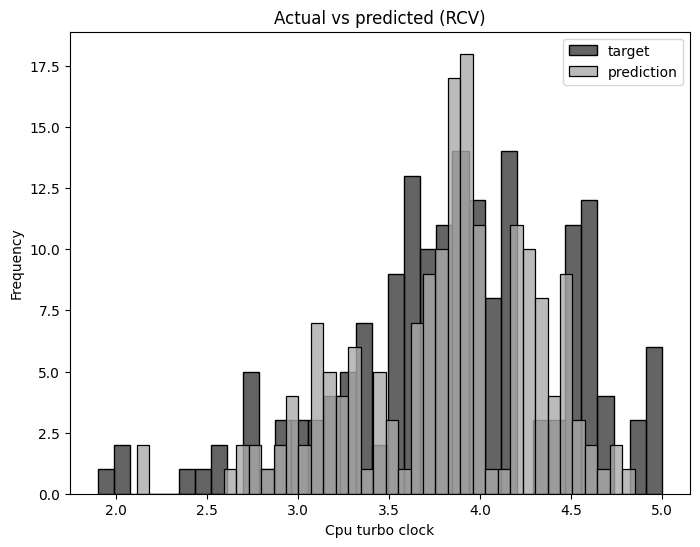

In [157]:
X_LBL = "Cpu turbo clock"
Y_LBL = "Frequency"
TRGT = "target"
PRDCT = "prediction"
CLR_1 = "#222222"
CLR_2 = "#aaaaaa"

fig_act_prd, (ax1) = plt.subplots(1, 1, figsize=(8, 6))

sns.histplot(y_vldtn, label=TRGT, color=CLR_1, alpha=0.7, bins=35, ax=ax1)
sns.histplot(y_prdct_vldtn, label=PRDCT, color=CLR_2, alpha=0.8, bins=40, ax=ax1)
ax1.set_title("Actual vs predicted (RCV)")
ax1.set_xlabel(X_LBL)
ax1.set_ylabel(Y_LBL)

plt.legend()
plt.show()

In [158]:
rmse_vldtn = rmse(y_vldtn, y_prdct_vldtn)
print(rmse_vldtn)

0.4490284319648869


In [159]:
r2_score(y_true=y_vldtn, y_pred=y_prdct_vldtn)

0.4927880725060365

In [160]:
mae_vldtn = mean_absolute_error(y_vldtn, y_prdct_vldtn)
print(mae_vldtn)

0.3428503139500616


Standardization can help to reduce the effect of values in the dataset that are higher in magnitude but it changes the interpretation of the model to be in terms of standard deviations

Not scaling the data and using units of measure that express a real scenario can help to make interpretability easier but can affect how the model or models chooses each feature and how significant it is to build the final model

I also added cpu_tdp feature even though it is correlated, I wanted to include it in the final model, the reason is that the power a cpu can draw affects its ability to increase turbo frequency of course this is not the only aspect to consider but recall is part of the only available data that theoretically is more significant than cpu_L1 and cpu_L2.

The linear model can be improved using Standardization, maybe apply Windsorization to outliers or remove them (observations were affected by duplicate removal) and running the process again but I have to test other models and deploy the best one, I may not have enough time for now but I can come back later and see what is the outcome.

I also removed a lot of output in this notebook to get a training script running with minor changes and of course a predict script too.

Creating a pipeline

In [161]:
print(selected_features)

['cpu_multiplier', 'cpu_prcss', 'cpu_clock', 'cpu_tdp']


In [162]:
cpu_tf_pl = make_pipeline(
    DictVectorizer(),
    LinearRegression()
)

In [163]:
type(train[selected_features])

pandas.core.frame.DataFrame

In [164]:
X_train_dct = train[selected_features].to_dict(orient='records')
cpu_tf_pl.fit(X_train_dct, y_train)

,steps,"[('dictvectorizer', ...), ('linearregression', ...)]"
,transform_input,None
,memory,None
,verbose,False
,dtype,<class 'numpy.float64'>
,separator,'='
,sparse,True
,sort,True
,fit_intercept,True
,copy_X,True
,tol,1e-06


In [165]:
import pickle

In [166]:
def save_pipeline(pipeline, filename):
    with open(filename, "wb") as outfile:
        pickle.dump(pipeline, outfile)
    print(f"Saved pipeline check cwd for: {filename}")

In [167]:
save_pipeline(cpu_tf_pl, "cpu_tf_mlrpl_v1.bin")

Saved pipeline check cwd for: cpu_tf_mlrpl_v1.bin


In [168]:
X_vldtn = vldtn[selected_features].to_dict(orient='records')
y_prdct_vldtn = cpu_tf_pl.predict(X_vldtn)

In [169]:
rmse_vldtn = rmse(y_vldtn, y_prdct_vldtn)
print(rmse_vldtn)

0.44795140192739785


In [170]:
r2_score(y_true=y_vldtn, y_pred=y_prdct_vldtn)

0.49521832988698355